<a href="https://colab.research.google.com/github/maclandrol/cours-ia-med/blob/master/06_Segmentation_MedSAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06. Segmentation d'Images Médicales avec MedSAM

**Enseignant:** Emmanuel Noutahi, PhD

---


## Objectifs

- Utiliser MedSAM pour segmenter des structures médicales
- Guider la segmentation avec des points
- Calculer des mesures cliniques (aire, diamètre)

## Qu'est-ce que la segmentation?

Délimiter précisément des structures dans une image:
- **Oncologie**: Mesurer une tumeur
- **Cardiologie**: Volume cardiaque
- **Chirurgie**: Planification pré-opératoire


## 1. Installation

In [1]:
!pip install -q transformers torch torchvision pillow matplotlib numpy scikit-image

In [79]:
import torch
from transformers import SamModel, SamProcessor
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
from skimage import transform as sktransform
from skimage import io as skio
from skimage import measure
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Device: cuda


## 2. Chargement de MedSAM

In [ ]:
print("Chargement de MedSAM...")

model = SamModel.from_pretrained("flaviagiammarino/medsam-vit-base")
processor = SamProcessor.from_pretrained("flaviagiammarino/medsam-vit-base")

model.to(device)
model.eval()

print("MedSAM chargé!")

## 3. Chargement d'une Image

Uploadez une image médicale (CT, IRM, radiographie, échographie, etc.)

In [69]:
from google.colab import files

def ensure_rgb(image):
    """
    Ensure image has shape (H, W, 3).
    """
    image = np.asarray(image)

    if image.ndim == 2:
        image = np.stack([image] * 3, axis=-1)
    elif image.ndim == 3 and image.shape[-1] == 4:
        image = image[..., :3]

    return image


def show_image_with_grid(image, step=50, figsize=(10, 10), annotate=True):
    h, w = image.shape[:2]

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image, cmap="gray" if image.ndim == 2 else None)

    xticks = np.arange(0, w, step)
    yticks = np.arange(0, h, step)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.grid(color="yellow", linestyle="--", linewidth=0.7, alpha=0.6)

    if annotate:
        ax.set_xticklabels([str(x) for x in xticks], fontsize=8)
        ax.set_yticklabels([str(y) for y in yticks], fontsize=8)
    else:
        ax.set_xticklabels([])
        ax.set_yticklabels([])

    ax.set_title(f"Image with grid (step={step}px)")
    plt.show()


def load_img(url=None, upload=False, show=True, figsize=(8, 8), grid_step=50):
    image = None

    if url is not None:
        image = skio.imread(url)

    elif upload:
        uploaded = files.upload()
        if uploaded:
            img_path = list(uploaded.keys())[0]
            image = skio.imread(img_path)

    if image is None:
        raise ValueError("Vous devez soit donner l'url soit mettre upload=True.")

    image = ensure_rgb(image)

    if show:
        show_image_with_grid(image, step=grid_step, figsize=figsize, annotate=True)

    return image

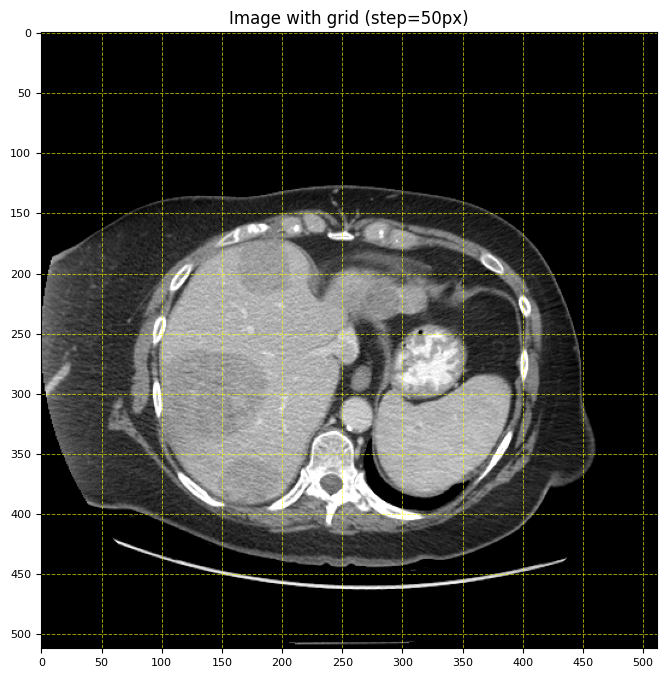

In [70]:
img_url = "https://huggingface.co/flaviagiammarino/medsam-vit-base/resolve/main/scripts/input.png"

image = load_img(url=img_url, show=True)

## 4. Segmentation Interactive

Guidez MedSAM avec des points:
- **Points positifs**: Structure à segmenter
- **Points négatifs** (optionnel): Zones à exclure

In [102]:
import numpy as np
import torch

def segment_medsam(
    image,
    input_points=None,
    input_labels=None,
    input_box=None,
    processor=processor,
    model=model,
    multimask_output=False
):
    if processor is None or model is None:
        raise ValueError("processor and model must be provided")

    kwargs = {"return_tensors": "pt"}

    use_points = (
        input_points is not None
        and input_labels is not None
        and len(input_points) > 0
        and len(input_labels) > 0
    )

    if use_points:
        if len(input_points) != len(input_labels):
            raise ValueError("input_points and input_labels must have the same length")
        kwargs["input_points"] = [[[list(map(float, pt)) for pt in input_points]]]
        kwargs["input_labels"] = [[list(map(int, input_labels))]]

    if input_box is not None:
        if len(input_box) != 4:
            raise ValueError("input_box must be [x_min, y_min, x_max, y_max]")

        # shape: (1, 1, 4)
        kwargs["input_boxes"] = [[[float(v) for v in input_box]]]

    if not use_points and input_box is None:
        raise ValueError("Give at least points or a box")

    inputs = processor(image, **kwargs)

    # Extra safety: force tensors if processor leaves lists behind
    if "input_boxes" in inputs and not isinstance(inputs["input_boxes"], torch.Tensor):
        inputs["input_boxes"] = torch.tensor(inputs["input_boxes"], dtype=torch.float32)

    if "input_points" in inputs and not isinstance(inputs["input_points"], torch.Tensor):
        inputs["input_points"] = torch.tensor(inputs["input_points"], dtype=torch.float32)

    if "input_labels" in inputs and not isinstance(inputs["input_labels"], torch.Tensor):
        inputs["input_labels"] = torch.tensor(inputs["input_labels"], dtype=torch.int64)

    inputs = {k: v.to(device) if hasattr(v, "to") else v for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, multimask_output=multimask_output)

    masks = processor.image_processor.post_process_masks(
        outputs.pred_masks.cpu(),
        inputs["original_sizes"].cpu(),
        inputs["reshaped_input_sizes"].cpu()
    )

    mask = masks[0][0]
    if mask.ndim == 3:
        mask = mask[0].numpy()
    else:
        mask = mask.numpy()

    return mask, outputs

In [103]:
def visualize_segmentation(image, mask, points=None, labels=None, box=None, alpha=0.4):
    mask = mask.astype(bool)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(image)

    if points is not None and labels is not None:
        pos_points = [p for p, l in zip(points, labels) if l == 1]
        neg_points = [p for p, l in zip(points, labels) if l == 0]

        if len(pos_points) > 0:
            pos_points = np.array(pos_points)
            axes[0].scatter(
                pos_points[:, 0], pos_points[:, 1],
                c="lime", marker="o", s=120,
                edgecolors="white", linewidths=2, label="Positive"
            )

        if len(neg_points) > 0:
            neg_points = np.array(neg_points)
            axes[0].scatter(
                neg_points[:, 0], neg_points[:, 1],
                c="red", marker="x", s=120,
                linewidths=2, label="Negative"
            )

    if box is not None:
        x0, y0, x1, y1 = box
        rect = Rectangle(
            (x0, y0), x1 - x0, y1 - y0,
            linewidth=2, edgecolor="cyan", facecolor="none"
        )
        axes[0].add_patch(rect)

    if points is not None or box is not None:
        axes[0].legend()

    axes[0].set_title("Image + Prompts")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Segmentation Mask")
    axes[1].axis("off")

    axes[2].imshow(image)
    overlay = np.zeros((*mask.shape, 4))
    overlay[mask] = [1, 0, 0, alpha]
    axes[2].imshow(overlay)

    if box is not None:
        x0, y0, x1, y1 = box
        rect = Rectangle(
            (x0, y0), x1 - x0, y1 - y0,
            linewidth=2, edgecolor="cyan", facecolor="none"
        )
        axes[2].add_patch(rect)

    axes[2].set_title("Overlay")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

## 5. Visualisation

### Segmentation avec points

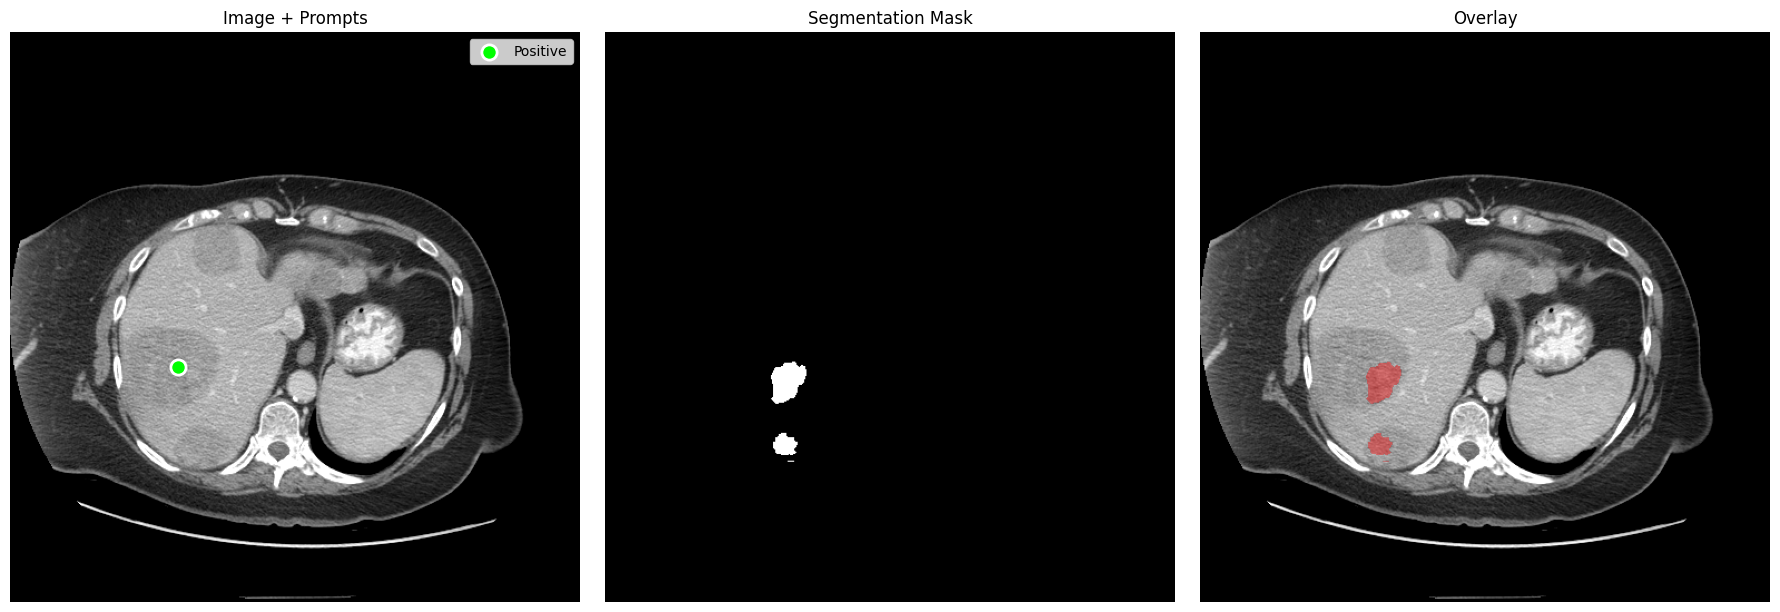

In [114]:
# MODIFIEZ ces coordonnées selon votre image
# Format: [x, y] pour chaque point
points_positifs = [[150, 300]]  # Point dans la structure à segmenter [[x1, y1], [x2, y2]]
points_negatifs = []  # Point à exclure [[x1, y1], [x2, y2]]

all_points = points_positifs + points_negatifs
all_labels = [1]*len(points_positifs) + [0] * len(points_negatifs)  # 1=positif, 0=négatif

mask, outputs = segment_medsam(
    image,
    all_points,
    all_labels,
)

visualize_segmentation(
    image,
    mask,
    all_points,
    all_labels,
)

### Segmentation avec mask

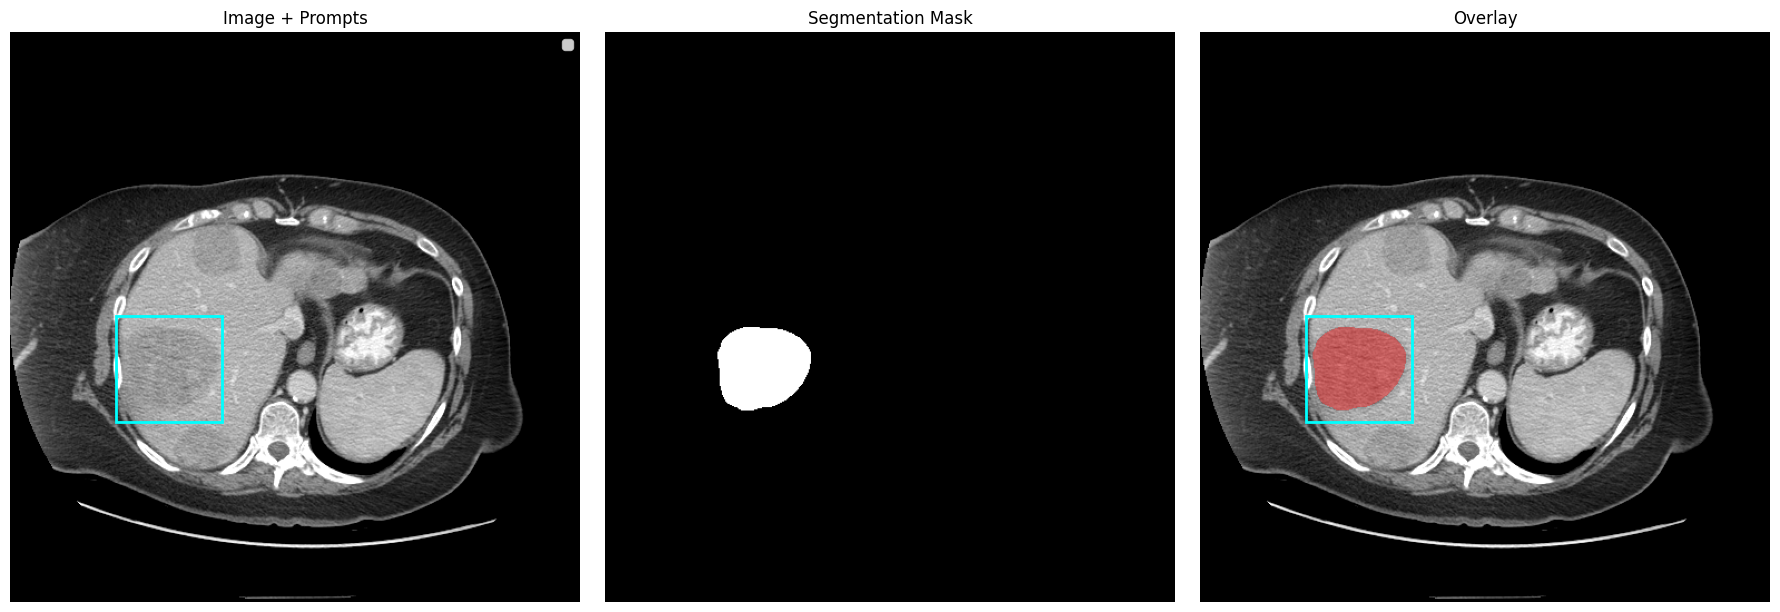

In [112]:
input_boxes = [95., 255., 190., 350.] # x1, y1, x2, y2 (deux points sur la diagonal)
mask, outputs = segment_medsam(
    image,
    input_box=input_boxes,
)

visualize_segmentation(
    image,
    mask,
    box=input_boxes

)

## 6. Mesures Cliniques

In [113]:
def compute_metrics(mask, pixel_size_mm=0.5):
    """Calcule mesures cliniques."""
    area_pixels = np.sum(mask)
    area_mm2 = area_pixels * (pixel_size_mm ** 2)

    # Diamètre équivalent
    diameter_mm = 2 * np.sqrt(area_mm2 / np.pi)

    # Contours
    contours = measure.find_contours(mask.astype(float), 0.5)
    perimeter_mm = len(contours[0]) * pixel_size_mm if contours else 0

    # Circularité
    circularity = (4 * np.pi * area_mm2) / (perimeter_mm ** 2) if perimeter_mm > 0 else 0

    return {
        'area_mm2': area_mm2,
        'diameter_mm': diameter_mm,
        'perimeter_mm': perimeter_mm,
        'circularity': circularity
    }

if 'mask' in locals():
    metrics = compute_metrics(mask)

    print("\nMESURES CLINIQUES")
    print("="*40)
    print(f"Aire:        {metrics['area_mm2']:.1f} mm²")
    print(f"Diamètre:    {metrics['diameter_mm']:.1f} mm")
    print(f"Périmètre:   {metrics['perimeter_mm']:.1f} mm")
    print(f"Circularité: {metrics['circularity']:.2f}")
    print("="*40)
    print("\nCircularité: 1.0 = cercle parfait")


MESURES CLINIQUES
Aire:        1263.0 mm²
Diamètre:    40.1 mm
Périmètre:   159.5 mm
Circularité: 0.62

Circularité: 1.0 = cercle parfait


## 7. Raffinement (Optionnel)

Si la segmentation n'est pas satisfaisante:
1. Retournez à la section 4
2. Ajoutez des points négatifs pour exclure des zones
3. Ou ajustez les points positifs

In [ ]:
# Exemple avec raffinement
# points_positifs = [250, 250]
# points_negatifs = [[300, 300], [200, 300]]  # Zones à exclure

print("Modifiez les points dans la section 4 et ré-exécutez.")

## 8. Points Clés

### Ce que vous avez appris:
- Segmenter des structures avec MedSAM
- Guider avec points positifs/négatifs
- Calculer mesures cliniques

### Applications:
- **Oncologie**: Mesure et suivi de tumeurs
- **Cardiologie**: Volumes cardiaques
- **Chirurgie**: Planification pré-opératoire

### Limites:
- Qualité d'image importante
- Validation par expert nécessaire
- Peut nécessiter plusieurs points